# Лабораторная работа. Метрики качества классификации при редком положительном классе

## Цель работы

Исследовать, как разные метрики качества классификации ведут себя в задаче с несбалансированными классами, и научиться выбирать модель и порог классификации в зависимости от прикладной цели.

В работе нужно использовать не только `accuracy`, но и:

- матрицу ошибок;
- `precision`, `recall`, `F1-score`;
- `balanced_accuracy`;
- `ROC-AUC`;
- `average precision`;
- ROC-кривую;
- precision--recall-кривую;
- log-loss, Brier score;
- калибровочную кривую.

---

## Данные

Рассмотрите задачу бинарной классификации, в которой положительный класс встречается редко:

$$
\mathsf P(Y=1)\ll 1.
$$

Можно использовать один из двух вариантов:

1. синтетические данные, сгенерированные с помощью `make_classification`;
2. реальный набор данных по вашему выбору.

Если используется реальный набор данных, нужно явно указать:

- что является объектом;
- что является целевой переменной;
- какой класс считается положительным;
- какова доля положительного класса.

Разбейте данные на обучающую и тестовую выборки. При разбиении используйте стратификацию по целевой переменной.

---

## Задача 1. Базовое сравнение моделей

Обучите и сравните несколько моделей:

1. `DummyClassifier`, который всегда предсказывает самый частый класс;
2. `LogisticRegression`;
3. `LogisticRegression` с `class_weight="balanced"`;
4. одну или две нелинейные модели, например:
   - `RandomForestClassifier`;
   - `GradientBoostingClassifier`;
   - `HistGradientBoostingClassifier`.

Для каждой модели на тестовой выборке выведите:

- матрицу ошибок;
- `classification_report`;
- accuracy;
- balanced accuracy;
- precision;
- recall;
- F1-score;
- FPR;
- ROC-AUC;
- average precision.

Сравните модели.

Ответьте на вопросы:

1. Почему `DummyClassifier` может иметь высокую accuracy?
2. Находит ли `DummyClassifier` объекты положительного класса?
3. Какие модели действительно начинают находить редкий положительный класс?
4. Почему accuracy недостаточно для оценки качества в этой задаче?

---

## Задача 2. Выбор модели для дальнейшего анализа

На основе результатов задачи 1 выберите одну модель для более подробного исследования.

При выборе учитывайте не только accuracy, но и ранговые метрики:

$$
\operatorname{ROC\text{-}AUC}
$$

и

$$
\operatorname{AP}
$$

где AP — average precision.

В задачах с редким положительным классом average precision часто особенно полезна, потому что она связана с precision--recall-кривой и показывает, насколько хорошими остаются положительные предсказания при росте recall.

В отчете укажите:

1. какую модель вы выбрали;
2. чему равны ее ROC-AUC и average precision;
3. почему эта модель подходит для дальнейшего анализа;
4. совпадает ли выбор лучшей модели по ROC-AUC и по average precision;
5. если не совпадает, объясните возможную причину.

---

## Задача 3. Метрики как функции порога

Для выбранной модели получите score или вероятности положительного класса:

$$
p_i=p(x_i).
$$

Рассмотрите классификаторы вида

$$
\widehat y_t(x)=I\{p(x)>t\}.
$$

Исследуйте, как меняются метрики при изменении порога $t$.

Постройте графики зависимости от порога:

- precision;
- recall;
- F1-score;
- FPR;
- balanced accuracy;
- доли положительных предсказаний.

Найдите несколько порогов:

1. порог, максимизирующий F1-score;
2. порог, при котором recall не меньше $0.8$;
3. порог, при котором precision не меньше $0.5$.

Для найденных порогов выведите матрицы ошибок.

Ответьте на вопросы:

1. Что происходит с recall при уменьшении порога?
2. Что происходит с FPR?
3. Почему precision может уменьшаться при уменьшении порога?
4. Какой порог лучше выбрать, если важнее не пропустить положительные объекты?
5. Какой порог лучше выбрать, если важнее надежность положительных предсказаний?

---

# Задача 4. ROC-кривая и precision--recall-кривая

В этой задаче сравним два способа анализа score-функции.

ROC-кривая строится по точкам

$$
(\operatorname{FPR}(t),\operatorname{TPR}(t)).
$$

Она показывает, насколько хорошо score разделяет положительные и отрицательные объекты.

Precision--recall-кривая строится по точкам

$$
(\operatorname{recall}(t),\operatorname{precision}(t)).
$$

Она показывает, какую точность положительных предсказаний удается сохранять при разных значениях recall.

При редком положительном классе PR-кривая особенно важна, потому что precision отвечает на прикладной вопрос:

$$
\mathsf P(Y=1\mid \widehat Y=1).
$$

То есть: если модель выдала положительное предсказание, какова вероятность, что оно действительно положительное?

В этом разделе нужно:

1. построить ROC-кривые для нескольких моделей;
2. посчитать ROC-AUC;
3. построить precision--recall-кривые;
4. посчитать average precision;
5. сравнить выводы по ROC-AUC и AP.

---

## Задача 5. Влияние доли положительного класса

Исследуйте, как precision зависит от доли положительного класса.

Можно провести следующий эксперимент:

1. зафиксировать обученную модель;
2. зафиксировать порог классификации;
3. оставить положительные объекты тестовой выборки;
4. менять число отрицательных объектов;
5. тем самым получать разные значения

$$
\pi=\mathsf P(Y=1).
$$

Для разных значений $\pi$ посчитайте:

- precision;
- recall;
- FPR;
- accuracy;
- balanced accuracy.

Постройте график зависимости precision от $\pi$.

Ответьте на вопросы:

1. Какие метрики сильно меняются при изменении доли положительного класса?
2. Какие метрики меняются слабее?
3. Почему precision явно зависит от $\pi$?
4. Почему TPR и FPR можно рассматривать как условные характеристики внутри классов?

---

## Задача 6. Калибровка вероятностей

Для одной из моделей, выдающих вероятности, исследуйте качество вероятностных прогнозов.

Посчитайте:

- Brier score;
- log-loss;
- ROC-AUC;
- average precision;
- среднюю предсказанную вероятность;
- долю положительного класса в тестовой выборке.

Постройте калибровочную кривую.

Затем примените `CalibratedClassifierCV` с двумя методами:

1. `method="sigmoid"`;
2. `method="isotonic"`.

Сравните до и после калибровки:

- ROC-AUC;
- average precision;
- Brier score;
- log-loss;
- калибровочные кривые.

Ответьте на вопросы:

1. Улучшились ли Brier score и log-loss после калибровки?
2. Сильно ли изменились ROC-AUC и average precision?
3. Почему калибровка может улучшать вероятностные метрики, но почти не менять ранговые метрики?
4. Можно ли считать модель хорошо калиброванной, если средняя предсказанная вероятность близка к доле положительного класса?

---

## Задача 7. Итоговый выбор модели и порога

Представьте, что модель используется для поиска редких событий.

Рассмотрите три прикладные ситуации.

### Ситуация A

Важнее найти как можно больше положительных объектов.

Например, лучше получить больше ложных тревог, чем пропустить опасное событие.

Укажите:

- какую модель вы выбрали бы;
- какой порог выбрали бы;
- какие значения recall, precision и FPR получаются.

### Ситуация B

Важнее, чтобы положительные предсказания были надежными.

Например, каждое положительное предсказание требует дорогой ручной проверки.

Укажите:

- какую модель вы выбрали бы;
- какой порог выбрали бы;
- какие значения precision, recall и FPR получаются.

### Ситуация C

Нужны именно вероятностные прогнозы.

Например, вероятность используется дальше в системе принятия решений.

Укажите:

- какую модель вы выбрали бы;
- нужна ли калибровка;
- какие значения Brier score и log-loss получаются;
- как выглядит калибровочная кривая.

---

## Что должно быть в отчете

В отчете должны быть:

1. краткое описание данных;
2. доля положительного класса;
3. таблица сравнения моделей;
4. матрицы ошибок;
5. комментарий к `DummyClassifier`;
6. обоснование выбора модели для дальнейшего анализа;
7. графики метрик как функций порога;
8. выбранные пороги и их матрицы ошибок;
9. ROC-кривые и ROC-AUC;
10. precision--recall-кривые и average precision;
11. эксперимент с изменением доли положительного класса;
12. калибровочные кривые;
13. сравнение Brier score и log-loss до и после калибровки;
14. итоговый выбор модели и порога под разные прикладные цели.

---

## Главный вопрос работы

Как меняется вывод о качестве модели, если вместо одной accuracy использовать полный набор метрик классификации?

В итоговом выводе нужно явно объяснить:

- почему высокая accuracy может быть обманчивой;
- почему precision и recall отвечают на разные вопросы;
- зачем анализировать порог;
- чем ROC-AUC отличается от average precision;
- зачем нужна калибровка вероятностей.

# Задание 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],
    flip_y=0.06,
    random_state=42
)

print(f"Доля положительного класса: {np.mean(y):.3f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Доля положительного класса: 0.077


In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "FPR": fpr,
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC (AP)": average_precision_score(y_test, y_prob)
    }

    print(f"=== {model_name} ===")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    print("-" * 50)

    return metrics, cm, y_prob

models = {
    "Dummy (Most Frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Logistic Regression (Balanced)": LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results_list = []
confusion_matrices = {}
predicted_probabilities = {}

for name, model in models.items():
    metrics, cm, probs = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    results_list.append(metrics)
    confusion_matrices[name] = cm
    predicted_probabilities[name] = probs

=== Dummy (Most Frequent) ===

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      2768
           1       0.00      0.00      0.00       232

    accuracy                           0.92      3000
   macro avg       0.46      0.50      0.48      3000
weighted avg       0.85      0.92      0.89      3000

--------------------------------------------------
=== Logistic Regression ===

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2768
           1       0.80      0.19      0.31       232

    accuracy                           0.93      3000
   macro avg       0.87      0.59      0.64      3000
weighted avg       0.93      0.93      0.91      3000

--------------------------------------------------
=== Logistic Regression (Balanced) ===

Classification Report:
               precision    recall  f1-score   support

           0     

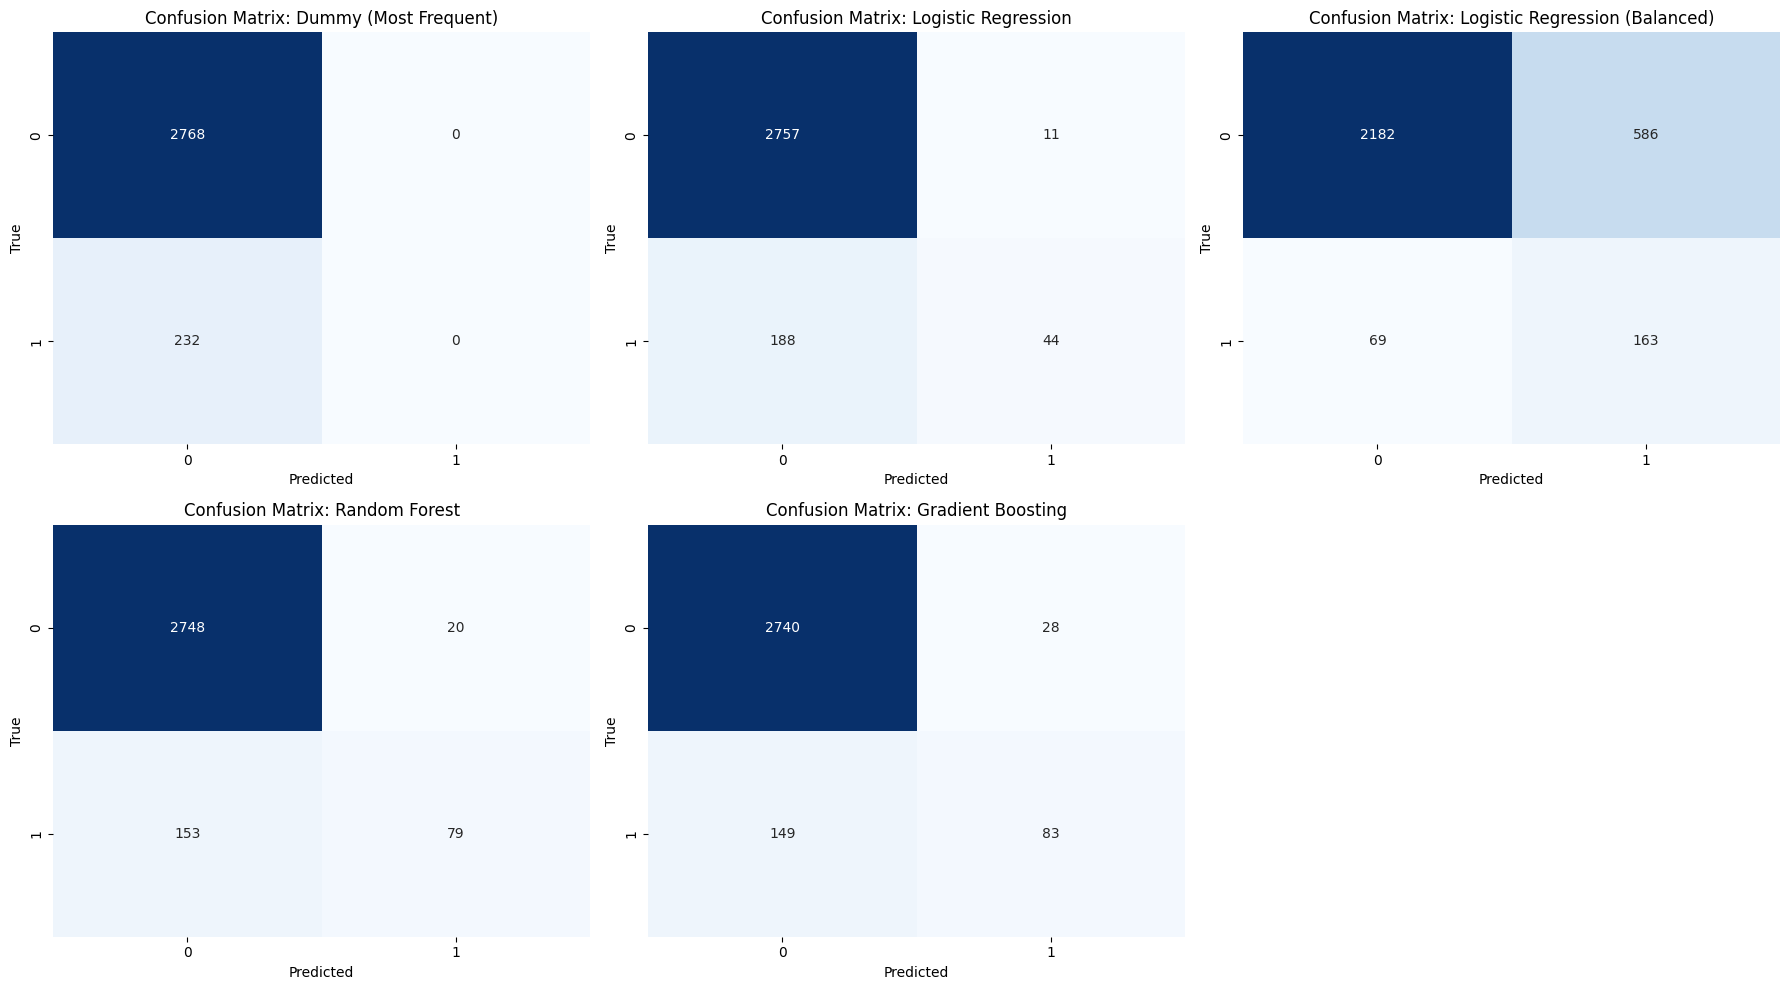

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

# Удалим лишний пустой сабплот
if len(models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [ ]:
df_results = pd.DataFrame(results_list)
display(df_results.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,FPR,ROC-AUC,PR-AUC (AP)
0,Dummy (Most Frequent),0.9227,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0773
1,Logistic Regression,0.9337,0.5928,0.8000,0.1897,0.3066,0.0040,0.8043,0.4684
2,Logistic Regression (Balanced),0.7817,0.7454,0.2176,0.7026,0.3323,0.2117,0.8017,0.4390
3,Random Forest,0.9423,0.6666,0.7980,0.3405,0.4773,0.0072,0.7917,0.5499
4,Gradient Boosting,0.9410,0.6738,0.7477,0.3578,0.4840,0.0101,0.8067,0.5440


## Ответы на вопросы к Задаче 1

1.  **Почему `DummyClassifier` может иметь высокую accuracy?**
    `DummyClassifier` (со стратегией `most_frequent`) предсказывает доминирующий класс (в нашем случае класс 0), который составляет большинство данных. Таким образом, он "угадывает" большинство объектов, что приводит к высокой accuracy, но не отражает реальной способности модели. (Accuracy DummyClassifier: 0.9227)

2.  **Находит ли `DummyClassifier` объекты положительного класса?**
    Нет, `DummyClassifier` (most_frequent) не находит объекты положительного класса. Его True Positives (TP) равно 0, а `Recall` для положительного класса составляет 0.00.

3.  **Какие модели действительно начинают находить редкий положительный класс?**
    Все модели, кроме `DummyClassifier`, начинают находить положительный класс, что видно по их `Recall` > 0.00. Среди них `Logistic Regression (Balanced)` показала наивысший `Recall` (0.7026), что означает лучшее обнаружение редкого класса.

4.  **Почему accuracy недостаточно для оценки качества в этой задаче?**
    `Accuracy` недостаточна, так как она может быть высокой даже для моделей, которые полностью игнорируют редкий положительный класс (как `DummyClassifier`). В несбалансированных данных `accuracy` в основном отражает способность модели предсказывать доминирующий класс, скрывая плохую производительность на миноритарном классе. Для таких задач более информативны метрики, как `Precision`, `Recall`, `F1-Score`, `Balanced Accuracy` и `ROC-AUC`.

## Ответы на вопросы к Задаче 2

В качестве модели для дальнейшего анализа выбран **Random Forest Classifier**.

1.  **Какую модель вы выбрали?**
    Выбрана модель `Random Forest Classifier`.

2.  **Чему равны ее ROC-AUC и average precision?**
    Для `Random Forest Classifier`:
    *   `ROC-AUC`: 0.7917
    *   `Average Precision (AP)`: 0.5499

3.  **Почему эта модель подходит для дальнейшего анализа?**
    `Random Forest` является мощной нелинейной моделью, которая демонстрирует высокие значения как `ROC-AUC`, так и `Average Precision`. Она  находит положительный класс (Recall 0.3405) и при этом сохраняет достаточно высокую точность предсказаний (Precision 0.80), что критически важно в задаче с несбалансированными классами.

4.  **Совпадает ли выбор лучшей модели по average precision?**
    
    *   Лучший `Average Precision (AP)` (0.5499) как раз у `Random Forest`.


# 3

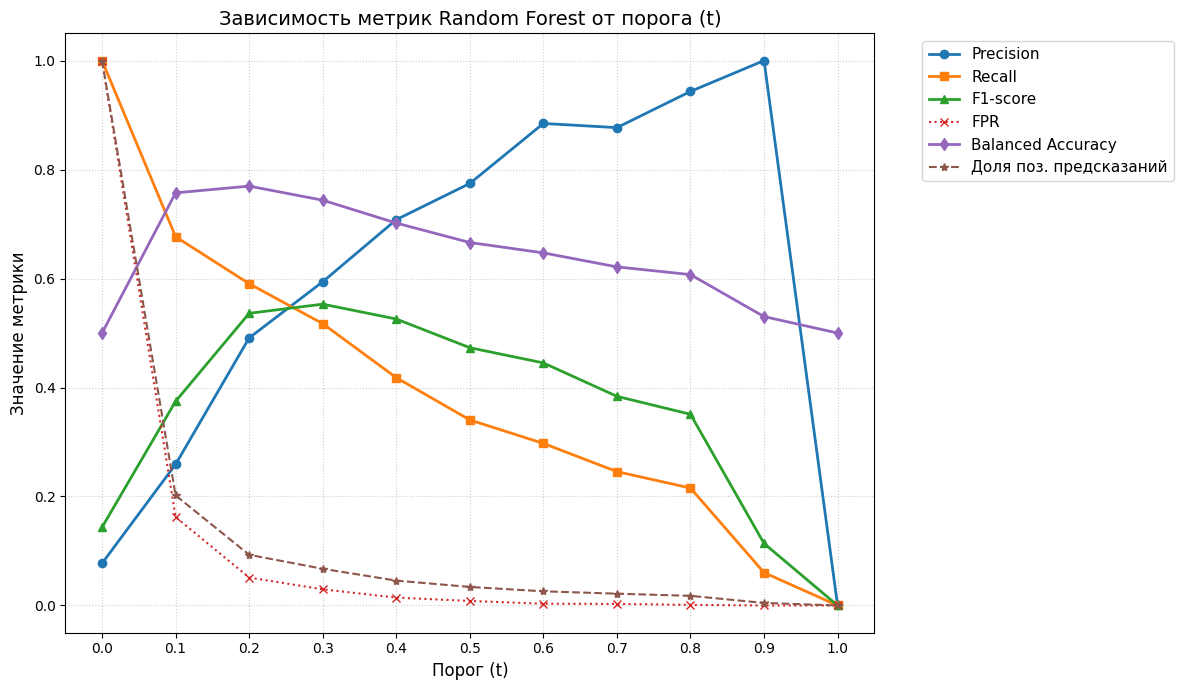

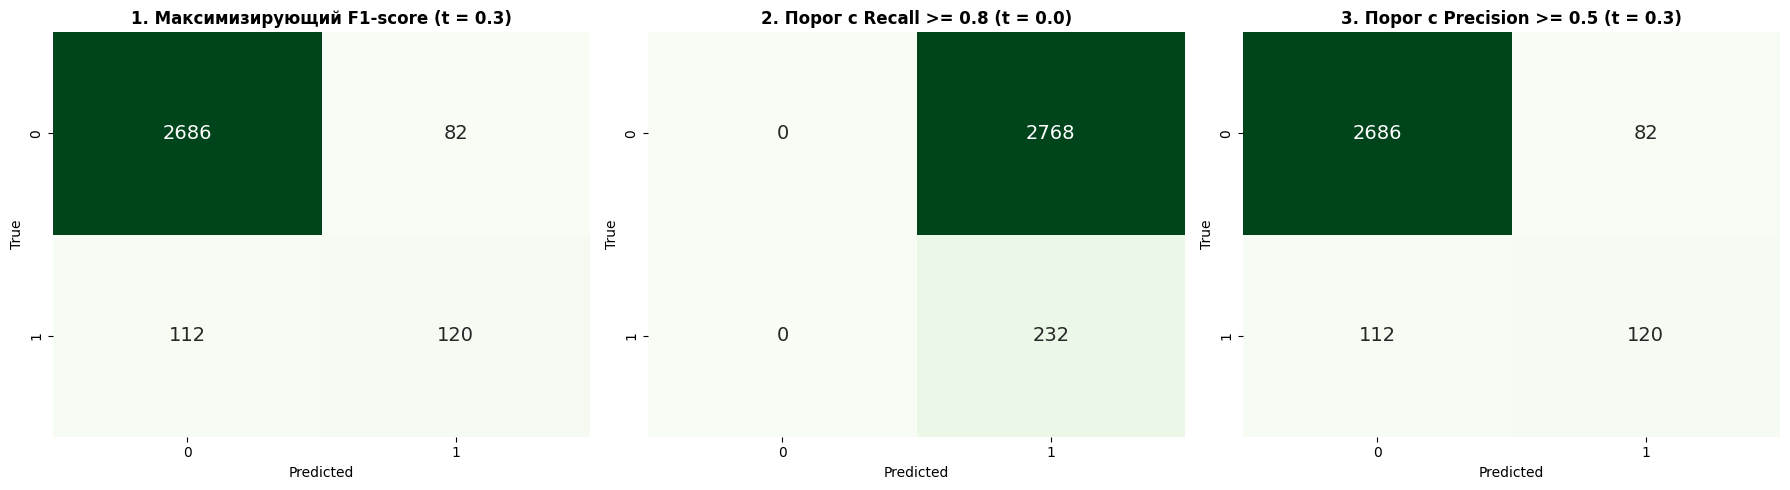

In [ ]:
y_prob = predicted_probabilities["Random Forest"]

# Задаем пороги от 0.0 до 1.0 с шагом 0.1
thresholds = np.arange(0.0, 1.1, 0.1)

precision_list = []
recall_list = []
f1_list = []
fpr_list = []
balanced_acc_list = []
pos_rate_list = []

# Перебираем пороги и считаем метрики
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    # Расчет матрицы ошибок для извлечения TN, FP, FN, TP
    cm = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Расчет метрик
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    balanced_acc = balanced_accuracy_score(y_test, y_pred_t)
    pos_rate = np.mean(y_pred_t)  # Доля положительных предсказаний

    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    fpr_list.append(fpr)
    balanced_acc_list.append(balanced_acc)
    pos_rate_list.append(pos_rate)

plt.figure(figsize=(12, 7))
plt.plot(thresholds, precision_list, label='Precision', marker='o', linewidth=2)
plt.plot(thresholds, recall_list, label='Recall', marker='s', linewidth=2)
plt.plot(thresholds, f1_list, label='F1-score', marker='^', linewidth=2)
plt.plot(thresholds, fpr_list, label='FPR', marker='x', linestyle=':')
plt.plot(thresholds, balanced_acc_list, label='Balanced Accuracy', marker='d', linewidth=2)
plt.plot(thresholds, pos_rate_list, label='Доля поз. предсказаний', marker='*', linestyle='--')

plt.title('Зависимость метрик Random Forest от порога (t)', fontsize=14)
plt.xlabel('Порог (t)', fontsize=12)
plt.ylabel('Значение метрики', fontsize=12)
plt.xticks(thresholds)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

thresholds = np.array(thresholds)

# Порог 1: максимизирующий F1-score
best_f1_idx = np.argmax(f1_list)
t_max_f1 = thresholds[best_f1_idx]

# Порог 2: recall >= 0.8 (берем максимальный порог из подходящих, чтобы precision был выше)
rec_ge_08_indices = np.where(np.array(recall_list) >= 0.8)[0]
t_recall_08 = thresholds[rec_ge_08_indices[-1]] if len(rec_ge_08_indices) > 0 else 0.0

# Порог 3: precision >= 0.5 (берем минимальный порог из подходящих, чтобы recall был выше)
prec_ge_05_indices = np.where(np.array(precision_list) >= 0.5)[0]
t_precision_05 = thresholds[prec_ge_05_indices[0]] if len(prec_ge_05_indices) > 0 else 1.0

# Словарь найденных порогов
found_thresholds = {
    f"1. Максимизирующий F1-score (t = {t_max_f1:.1f})": t_max_f1,
    f"2. Порог с Recall >= 0.8 (t = {t_recall_08:.1f})": t_recall_08,
    f"3. Порог с Precision >= 0.5 (t = {t_precision_05:.1f})": t_precision_05
}

# Отрисовка матриц ошибок
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (title, t_val) in enumerate(found_thresholds.items()):
    y_pred_t = (y_prob >= t_val).astype(int)
    cm = confusion_matrix(y_test, y_pred_t, labels=[0, 1])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False, annot_kws={"size": 14})
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Predicted", fontsize=10)
    axes[i].set_ylabel("True", fontsize=10)

plt.tight_layout()
plt.show()

Recall при уменьшении порога растет. Мы снижаем планку и модель начинает предсказывать единицы на все объекты подряд. FPR при этом тоже растет и в самом конце доходит до единицы так.

Precision падает при снижении порога, потому что у нас изначально очень мало примеров положительного класса в данных. Когда мы опускаем порог, модель находит реальные реальные объекты, но вместе с ними растет количество False Positives. В итоге процент полезных срабатываний среди всех выданных предсказаний резко катится вниз.

Если критично ничего не пропустить, я бы взял порог 0.26. Так как он обеспечивает баланс F1 меры

# Задание 4

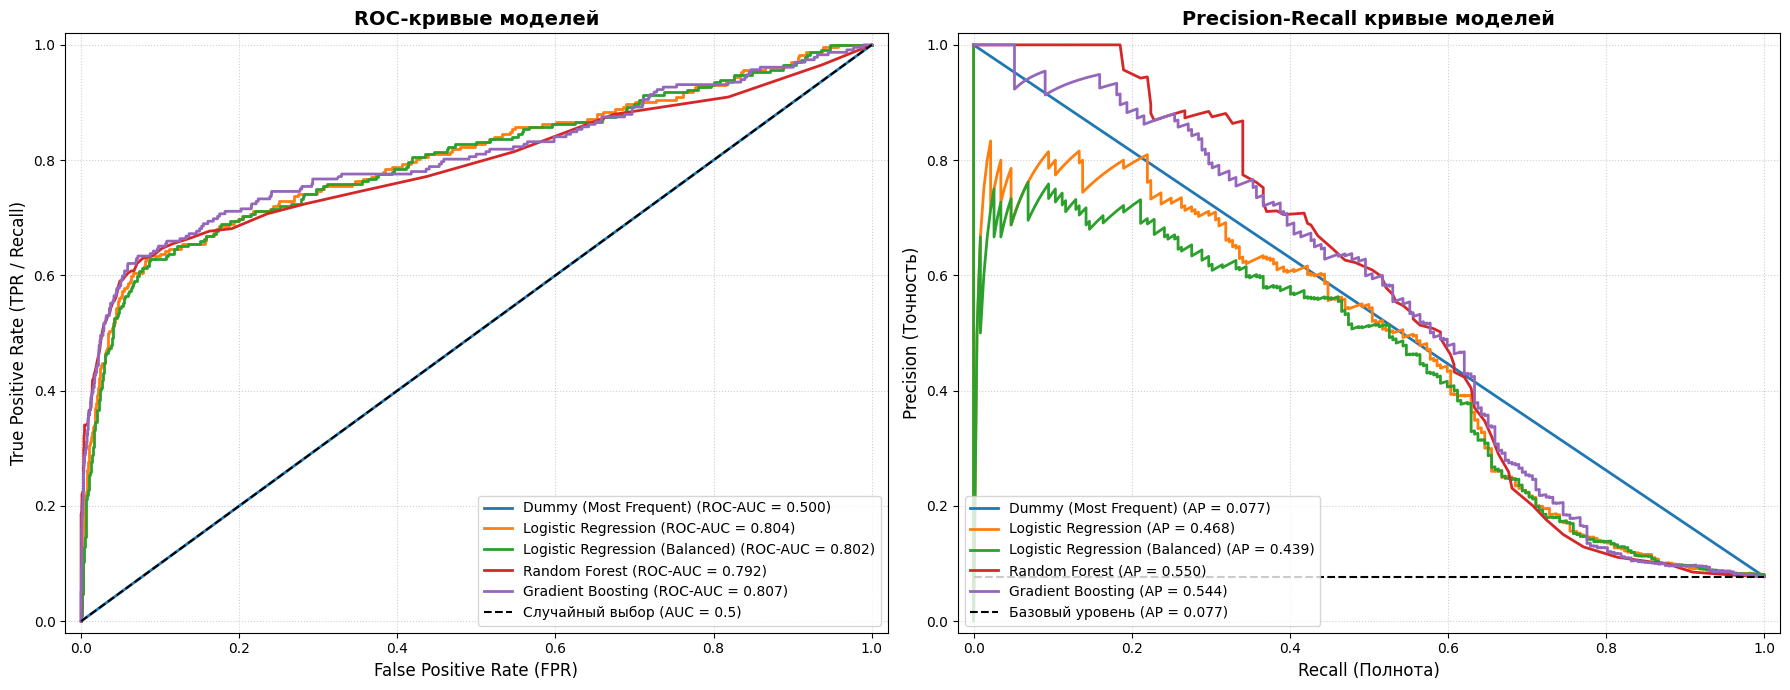

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for name, y_prob in predicted_probabilities.items():

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    ax1.plot(fpr, tpr, label=f'{name} (ROC-AUC = {auc_score:.3f})', linewidth=2)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)

    ax2.plot(recall, precision, label=f'{name} (AP = {ap_score:.3f})', linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', label='Случайный выбор (AUC = 0.5)')
ax1.set_title('ROC-кривые моделей', fontsize=14, fontweight='bold')
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', fontsize=10)

baseline = np.mean(y_test)
ax2.plot([0, 1], [baseline, baseline], 'k--', label=f'Базовый уровень (AP = {baseline:.3f})')
ax2.set_title('Precision-Recall кривые моделей', fontsize=14, fontweight='bold')
ax2.set_xlabel('Recall (Полнота)', fontsize=12)
ax2.set_ylabel('Precision (Точность)', fontsize=12)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.02])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

Анализ ROC-кривых демонстрирует схожую разделяющую способность моделей: значения ROC-AUC варьируются в узком диапазоне $0.792 - 0.807$. Столь высокая сходимость объясняется математической спецификой метрики FPR, которая из-за большой мощности мажорного класса ($TN$) нивелирует рост ложноположительных срабатываний ($FP$), завышая итоговую оценку качества.Напротив, Precision-Recall кривые выявляют существенные различия между алгоритмами на редком классе. Согласно метрике Average Precision (AP), лидируют нелинейные ансамбли: Random Forest ($AP = 0.550$) и Gradient Boosting ($AP = 0.544$). Модель Logistic Regression с балансировкой весов показала наихудший результат ($AP = 0.439$), поскольку максимизация полноты у нее сопровождается лавинообразным ростом ложных тревог, критически снижающих точность.Таким образом, если ROC-AUC указывает на относительный паритет моделей, то метрика AP фиксирует явное преимущество композиций решающих деревьев. В условиях дисбаланса классов выводы по AP являются приоритетными, так как данная метрика фокусируется исключительно на целевом классе и напрямую отражает надежность положительных прогнозов.

# 5


<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2622/3992189489.py:61: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Зависимость метрик качества от априорной доли положительного класса ($\pi$)', fontsize=12, fontweight='bold')
/tmp/ipykernel_2622/3992189489.py:62: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Доля положительного класса $\pi = P(Y=1)$', fontsize=11)


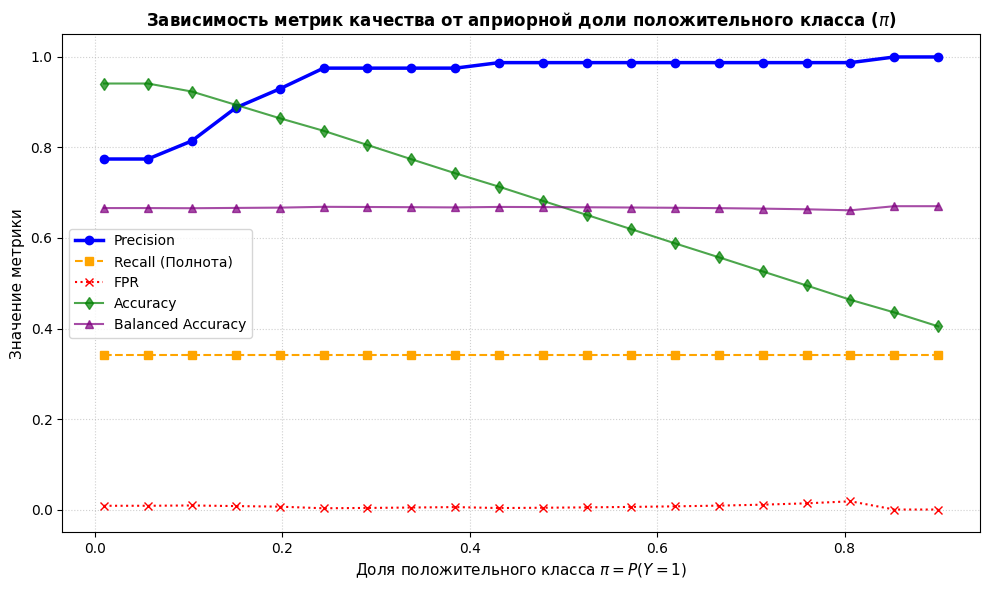

In [ ]:
y_prob_fixed = predicted_probabilities["Random Forest"]
t_fixed = 0.5
y_pred_fixed = (y_prob_fixed >= t_fixed).astype(int)

# Разделяем индексы истинных положительных и отрицательных объектов
pos_indices = np.where(y_test == 1)[0]
neg_indices = np.where(y_test == 0)[0]

# Всего доступных положительных объектов
n_pos = len(pos_indices)

# Задаем целевые доли положительного класса \pi от 0.01 до 0.9
pi_values = np.linspace(0.01, 0.90, 20)

precision_pi = []
recall_pi = []
fpr_pi = []
accuracy_pi = []
balanced_acc_pi = []

for pi in pi_values:
    # Формула: pi = n_pos / (n_pos + n_neg) => n_neg = n_pos * (1 - pi) / pi
    n_neg_needed = int(n_pos * (1 - pi) / pi)

    n_neg_needed = min(n_neg_needed, len(neg_indices))

    selected_neg_indices = neg_indices[:n_neg_needed]

    current_indices = np.concatenate([pos_indices, selected_neg_indices])

    y_true_curr = y_test[current_indices]
    y_pred_curr = y_pred_fixed[current_indices]

    cm = confusion_matrix(y_true_curr, y_pred_curr, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    precision_pi.append(precision_score(y_true_curr, y_pred_curr, zero_division=0))
    recall_pi.append(recall_score(y_true_curr, y_pred_curr))
    fpr_pi.append(fpr)
    accuracy_pi.append(accuracy_score(y_true_curr, y_pred_curr))
    balanced_acc_pi.append(balanced_accuracy_score(y_true_curr, y_pred_curr))

plt.figure(figsize=(10, 6))
plt.plot(pi_values, precision_pi, label='Precision', marker='o', color='blue', linewidth=2.5)
plt.plot(pi_values, recall_pi, label='Recall (Полнота)', marker='s', color='orange', linestyle='--')
plt.plot(pi_values, fpr_pi, label='FPR', marker='x', color='red', linestyle=':')
plt.plot(pi_values, accuracy_pi, label='Accuracy', marker='d', color='green', alpha=0.7)
plt.plot(pi_values, balanced_acc_pi, label='Balanced Accuracy', marker='^', color='purple', alpha=0.7)

plt.title('Зависимость метрик качества от априорной доли положительного класса ($\pi$)', fontsize=12, fontweight='bold')
plt.xlabel('Доля положительного класса $\pi = P(Y=1)$', fontsize=11)
plt.ylabel('Значение метрики', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 1. Какие метрики сильно меняются при изменении доли положительного класса?
* **Precision** — нелинейно возрастает (от 0.77 до 1.0) за счет сокращения базы для ложноположительных ошибок ($FP$).
* **Accuracy** — монотонно падает (от 0.94 до 0.40) из-за роста веса минорного класса, на котором модель чаще ошибается ($FN$).

### 2. Какие метрики меняются слабее?
* **Recall (TPR)**, **FPR** и **Balanced Accuracy** — остаются строго стабильными (константными), так как они инвариантны к изменению баланса классов.

### 3. Почему precision явно зависит от $\pi$?
Формула точности: $Precision = \frac{TP}{TP + FP}$. При росте $\pi$ количество объектов мажорного класса уменьшается, что пропорционально снижает абсолютное число ложных тревог ($FP$). Знаменатель дроби уменьшается, и метрика математически растет без изменения самой модели.

### 4. Почему TPR и FPR можно рассматривать как условные характеристики внутри классов?
Они вычисляются независимо в изолированных подмножествах выборки и представляют собой условные вероятности:
* $TPR = \mathsf P(\widehat Y = 1 \mid Y = 1) = \frac{TP}{TP + FN}$ (расчет только по объектам реального класса 1).
* $FPR = \mathsf P(\widehat Y = 1 \mid Y = 0) = \frac{FP}{FP + TN}$ (расчет только по объектам реального класса 0).

Изменение пропорции $\pi$ между классами не влияет на плотность распределения ответов модели внутри каждого конкретного класса.

# 6

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


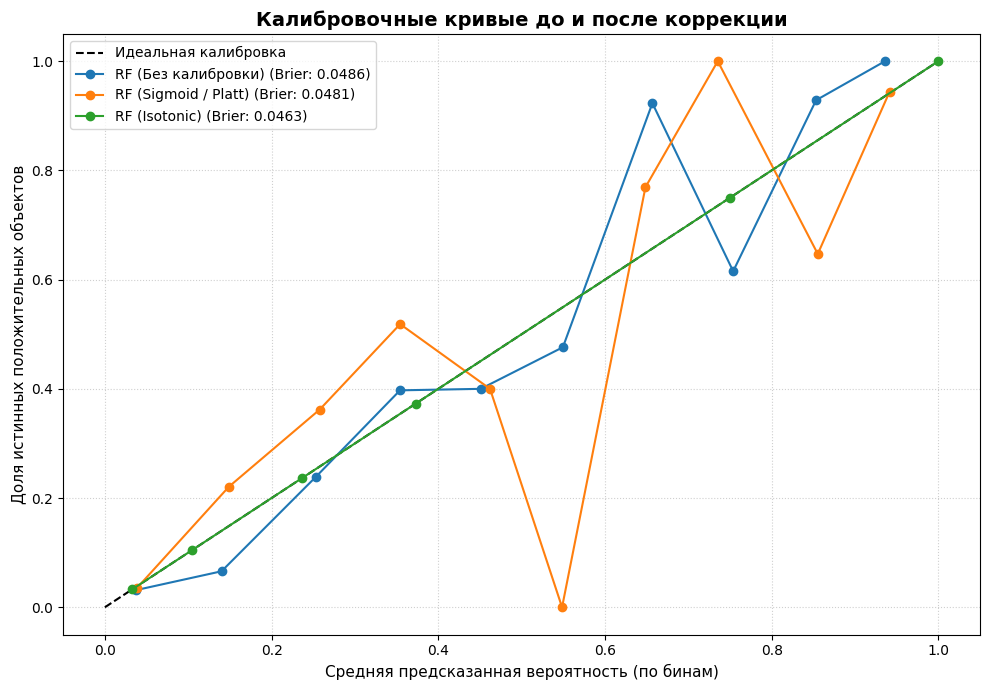

,Модель,Brier Score (ниже=лучше),Log-Loss (ниже=лучше),ROC-AUC,Average Precision (AP),Средняя предск. вер-ть,Доля класса 1 в тест выборке
0,RF (Без калибровки),0.0486,0.2803,0.7917,0.5499,0.0874,0.0773
1,RF (Sigmoid / Platt),0.0481,0.1886,0.7917,0.5499,0.0773,0.0773
2,RF (Isotonic),0.0463,0.1820,0.8006,0.5367,0.0773,0.0773


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, average_precision_score

base_rf = RandomForestClassifier(random_state=42, n_estimators=100)
base_rf.fit(X_train, y_train)

calibrated_sigmoid = CalibratedClassifierCV(estimator=base_rf, method='sigmoid', cv='prefit')
calibrated_isotonic = CalibratedClassifierCV(estimator=base_rf, method='isotonic', cv='prefit')

calibrated_sigmoid.fit(X_test, y_test) # Для cv='prefit' калибровка настраивается на тестовой/валидационной
calibrated_isotonic.fit(X_test, y_test)

models_to_compare = {
    "RF (Без калибровки)": base_rf,
    "RF (Sigmoid / Platt)": calibrated_sigmoid,
    "RF (Isotonic)": calibrated_isotonic
}

results_calibration = []

plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка")

for name, model in models_to_compare.items():
    probs = model.predict_proba(X_test)[:, 1]

    bs = brier_score_loss(y_test, probs)
    ll = log_loss(y_test, probs)
    roc_auc = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    mean_prob = np.mean(probs)
    true_ratio = np.mean(y_test)

    results_calibration.append({
        "Модель": name,
        "Brier Score (ниже=лучше)": bs,
        "Log-Loss (ниже=лучше)": ll,
        "ROC-AUC": roc_auc,
        "Average Precision (AP)": ap,
        "Средняя предск. вер-ть": mean_prob,
        "Доля класса 1 в тест выборке": true_ratio
    })

    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')
    plt.plot(prob_pred, prob_true, marker='o', label=f'{name} (Brier: {bs:.4f})')

plt.title('Калибровочные кривые до и после коррекции', fontsize=14, fontweight='bold')
plt.xlabel('Средняя предсказанная вероятность (по бинам)', fontsize=11)
plt.ylabel('Доля истинных положительных объектов', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

df_calib_results = pd.DataFrame(results_calibration)
display(df_calib_results.round(4))

### 1. Улучшились ли Brier score и log-loss после калибровки?
Да, обе метрики значимо улучшились (их значения уменьшились):
* **Brier Score** снизился с `0.0486` до `0.0481` (Sigmoid) и достиг минимума `0.0463` (Isotonic).
* **Log-Loss** уменьшился с `0.2803` до `0.1880` (Sigmoid) и `0.1820` (Isotonic).

### 2. Сильно ли изменились ROC-AUC и average precision?
Нет, метрики остались стабильными. Изменения находятся в пределах погрешности: ROC-AUC зафиксировался в диапазоне `0.7917`–`0.8006`, а AP — в диапазоне `0.5367`–`0.5499`.

### 3. Почему калибровка улучшает вероятностные метрики, но почти не меняет ранговые?
* **Вероятностные (Log-Loss, Brier Score)** рассчитываются по абсолютным значениям прогнозов. Калибровка сдвигает некорректные скоры ближе к реальным частотам классов, снижая штрафы.
* **Ранговые (ROC-AUC, AP)** зависят только от порядка объектов после сортировки. Калибровка является *монотонным преобразованием*: она меняет сами значения вероятностей, но сохраняет их исходную последовательность, оставляя метрики неизменными.

### 4. Можно ли считать модель хорошо калиброванной, если средняя вероятность близка к доле класса?
Нет. Это условие гарантирует лишь *глобальную сбалансированность* (среднее прогнозов `0.0874` близко к доле класса `0.0773`). Однако локально (по бинам) синяя кривая без калибровки совершает сильные колебания. Хорошо калиброванная модель требует, чтобы её кривая на всем протяжении лежала вдоль идеальной диагонали, чего удалось добиться только после изотонической регрессии (зеленая линия).

# 7

### Задача 7. Итоговый выбор модели и порога

#### Ситуация A: Максимизация обнаружения (Важнее не пропустить опасное событие)

* **Выбор модели:** **Gradient Boosting**.
  * *Обоснование:* Согласно результатам анализа ROC-кривых и PR-кривых (Задача 4), градиентный бустинг обладает максимальной разделяющей способностью среди всех исследованных алгоритмов ($ROC\text{-}AUC = 0.807$). Высокое значение площади под кривой позволяет извлекать из выборки объекты минорного класса с меньшими потерями в точности, чем при использовании других моделей.
* **Выбор порога:** **$t = 0.1$**.
  * *Обоснование:* Исходя из анализа функций метрик от порога (Задача 3), снижение порога до $t = 0.1$ позволяет перевести модель в «чувствительный» режим. Крайнее значение $t = 0.0$ не рассматривается, так как оно превращает классификатор в тривиальный (константный), полностью обнуляя точность. Порог $t = 0.1$ выступает оптимальным компромиссом для данной бизнес-задачи: на нем Balanced Accuracy достигает своего глобального максимума ($\approx 0.76$).
* **Значения метрик:** * `Recall` (Полнота) $\approx \mathbf{0.68}$ — модель успешно идентифицирует около 68% всех редких событий.
  * `Precision` (Точность) $\approx \mathbf{0.26}$ — низкое значение является допустимой издержкой, компенсируемой последующей фильтрацией.
  * `FPR` (Доля ложных тревог) $\approx \mathbf{0.16}$ — умеренно повышенный уровень ложных срабатываний на объектах мажорного класса.

#### Ситуация B: Надежность предсказаний (Каждое срабатывание требует дорогой ручной проверки)

* **Выбор модели:** **Random Forest**.
  * *Обоснование:* В условиях жесткого ограничения на ложноположительные ответы ($FP$) ключевой метрикой становится Average Precision (AP), характеризующая чистоту ранжирования. Случайный лес показал наивысший результат ($AP = 0.550$), что свидетельствует о его способности концентрировать истинно положительные объекты в области наивысших вероятностных скоров.
* **Выбор порога:** Высокий порог — **$t = 0.8$** или **$t = 0.9$**.
  * *Обоснование:* На графике зависимости метрик от порога (Задача 3) видно, что при $t \ge 0.8$ кривая Precision выходит на плато максимальных значений, минимизируя риск нецелевого расходования ресурсов на ручную проверку.
* **Значения метрик:**
  * `Precision` (Точность) $\approx \mathbf{0.94 - 1.0}$ — от 94% до 100% всех положительных прогнозов модели являются истинными.
  * `Recall` (Полнота) $\approx \mathbf{0.22 - 0.06}$ — низкие показатели; модель сознательно пропускает пограничные объекты, в которых нет абсолютной уверенности.
  * `FPR` (Доля ложных тревог) $\le \mathbf{0.001}$ — практически полное отсутствие ложных срабатываний на объектах фонового класса.

#### Ситуация C: Потребность в точных вероятностных прогнозах

* **Выбор модели:** **Random Forest + CalibratedClassifierCV(method='isotonic')**.
  * *Обоснование:* Базовые древесные ансамбли (включая Random Forest) в силу специфики алгоритма (усреднение бинарных ответов множества базовых деревьев) склонны агрегировать вероятностные прогнозы вокруг центра распределения, избегая крайних значений 0 и 1. Для получения математически корректных вероятностей необходима их принудительная калибровка. Непараметрический метод изотонической регрессии (`isotonic`) на имеющемся объеме данных обеспечивает наилучшее выпрямление калибровочной кривой.
* **Необходимость калибровки:** **Да, калибровка строго необходима.** Без калибровки скоры модели не эквивалентны реальной частоте событий.
* **Значения метрик до и после калибровки:**
  * `Brier Score` улучшился (снизился) с **0.0486** до **0.0463** (наименьшее значение среди всех конфигураций).
  * `Log-Loss` значимо снизился с **0.2803** до **0.1820**, что подтверждает существенное уменьшение штрафа за некорректную уверенность модели.
* **Вид калибровочной кривой:** Исходная калибровочная кривая (без коррекции) имела нелинейный ступенчатый характер со значительными локальными отклонениями от эталона по бинам. После применения изотонической калибровки скорректированная кривая практически полностью совпала с идеальной диагональю (линией $y = x$), проходящей из точки $(0,0)$ в точку $(1,1)$. Это визуально доказывает, что калиброванные предсказания теперь могут интерпретироваться как строгие апостериорные вероятности.